In [14]:

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

from collections import Counter
import re
from typing import List, Dict

In [15]:
df = pd.read_json("../datasets/fixed_dataset.json")
print(f"Total papers: {len(df)}")

Total papers: 121


In [16]:
def clean_text(text: str) -> str:
    """
    Applies basic text cleaning: lowercase, remove special chars.
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Remove non-alphanumeric characters (keep spaces)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text




=== Class Distribution ===
                         count
plan-generation             53
language-translation        23
interactive-planning        21
model-construction          17
heuristics-optimization      8
tool-integration             8
brain-inspired-planning      5
multiagent-planning          5


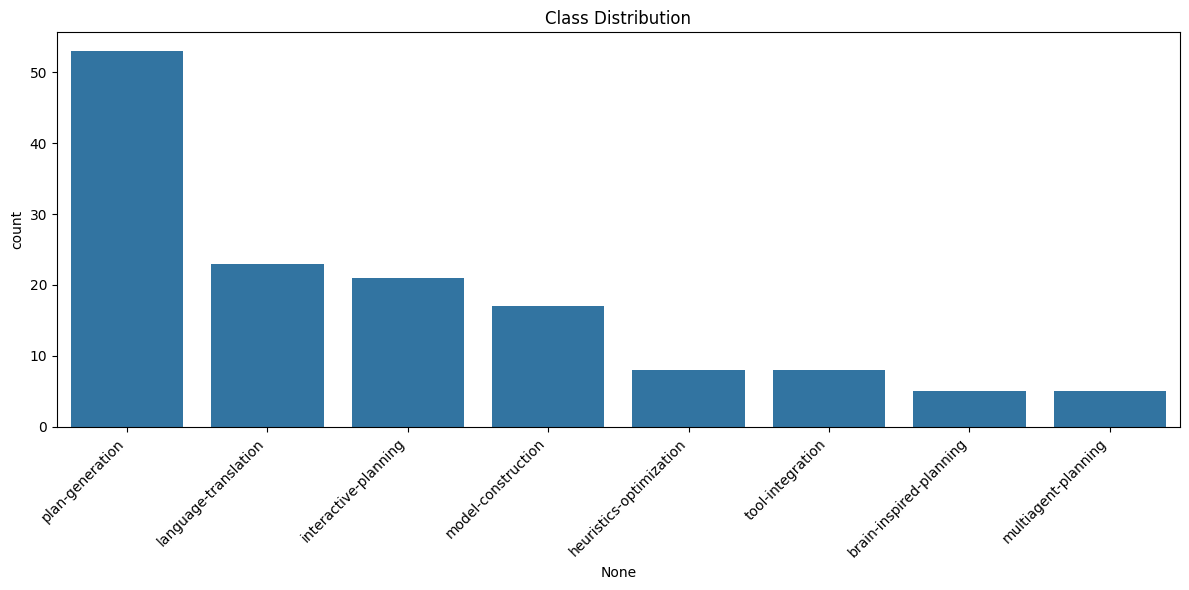

In [17]:
print("\n=== Class Distribution ===")
all_categories = []
# Handle potentially mixed types or csv-like strings
for item in df['category']:
    if isinstance(item, str):
        # Split by comma if multiple categories are present
        cats = [c.strip() for c in item.split(',')]
        all_categories.extend(cats)
    elif isinstance(item, list):
        all_categories.extend(item)
        
cat_counts = Counter(all_categories)
cat_df = pd.DataFrame.from_dict(cat_counts, orient='index', columns=['count']).sort_values('count', ascending=False)
print(cat_df)

plt.figure(figsize=(12, 6))
sns.barplot(x=cat_df.index, y=cat_df['count'] if not cat_df.empty else [])
plt.title("Class Distribution")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [18]:
df['text'] = df['title'] + " " + df['abstract']
df['clean_text'] = df['text'].apply(clean_text)

def get_primary(cat):
    if isinstance(cat, str):
        return cat.split(',')[0].strip()

df["primary_category"] = df["category"].apply(get_primary)

unique_cats = df['primary_category'].unique()
print(f"Unique Primary Categories: {len(unique_cats)}")

# Vectorization (TF-IDF)
print("\nVectorizing text...")
tfidf = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1,2), min_df=4, max_df=0.6)
X = tfidf.fit_transform(df['clean_text'])
feature_names = np.array(tfidf.get_feature_names_out())

Unique Primary Categories: 8

Vectorizing text...



=== Similarity (Cosine) ===
Average Intra-class Similarity: 0.0910
Average Inter-class Similarity: 0.0816
Ratio (Intra/Inter): 1.1155


/tmp/ipykernel_4631/2408548211.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([intra_sims, inter_sims], labels=['Intra-class', 'Inter-class'])


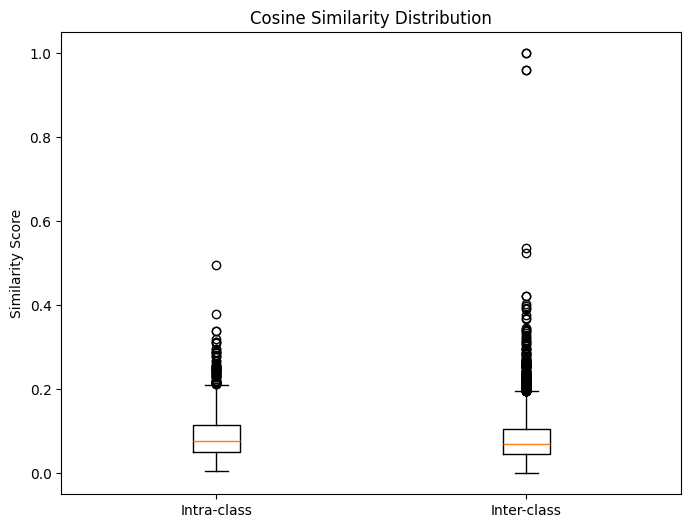

In [19]:
print("\n=== Similarity (Cosine) ===")

# Calculate cosine similarity matrix
sim_matrix = cosine_similarity(X)

intra_sims = []
inter_sims = []

labels = df['primary_category'].values
# Use indices for upper triangle to avoid duplicates and self-similarity
rows, cols = np.triu_indices(len(df), k=1)

for r, c in zip(rows, cols):
    sim = sim_matrix[r, c]
    if labels[r] == labels[c]:
        intra_sims.append(sim)
    else:
        inter_sims.append(sim)
        
avg_intra = np.mean(intra_sims) if intra_sims else 0
avg_inter = np.mean(inter_sims) if inter_sims else 0

print(f"Average Intra-class Similarity: {avg_intra:.4f}")
print(f"Average Inter-class Similarity: {avg_inter:.4f}")
print(f"Ratio (Intra/Inter): {avg_intra/avg_inter:.4f}" if avg_inter > 0 else "Ratio: N/A")

plt.figure(figsize=(8, 6))
plt.boxplot([intra_sims, inter_sims], labels=['Intra-class', 'Inter-class'])
plt.title("Cosine Similarity Distribution")
plt.ylabel("Similarity Score")

plt.show()

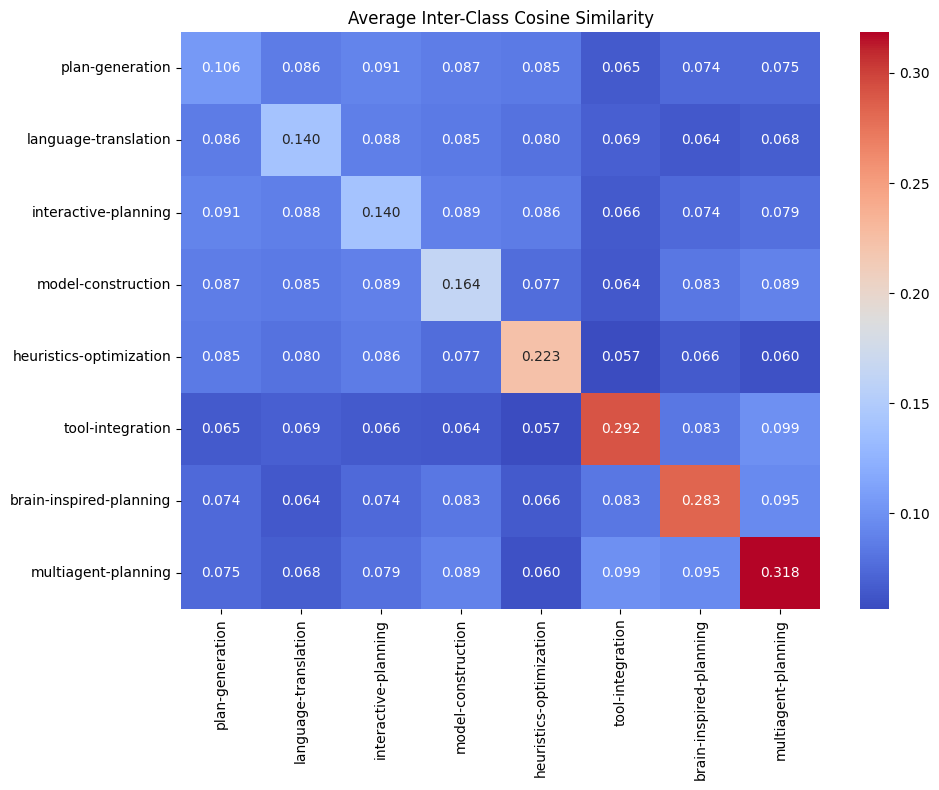

In [20]:
cat_list = list(unique_cats)
class_sim_matrix = np.zeros((len(cat_list), len(cat_list)))

for i, cat1 in enumerate(cat_list):
    for j, cat2 in enumerate(cat_list):
        idx1 = df[df['primary_category'] == cat1].index
        idx2 = df[df['primary_category'] == cat2].index
        class_sim_matrix[i,j] = cosine_similarity(X[idx1], X[idx2]).mean()

plt.figure(figsize=(10, 8))
sns.heatmap(class_sim_matrix, xticklabels=cat_list, yticklabels=cat_list, 
            annot=True, fmt='.3f', cmap='coolwarm')
plt.title("Average Inter-Class Cosine Similarity")
plt.tight_layout()
plt.show()


=== t-SNE Visualization ===


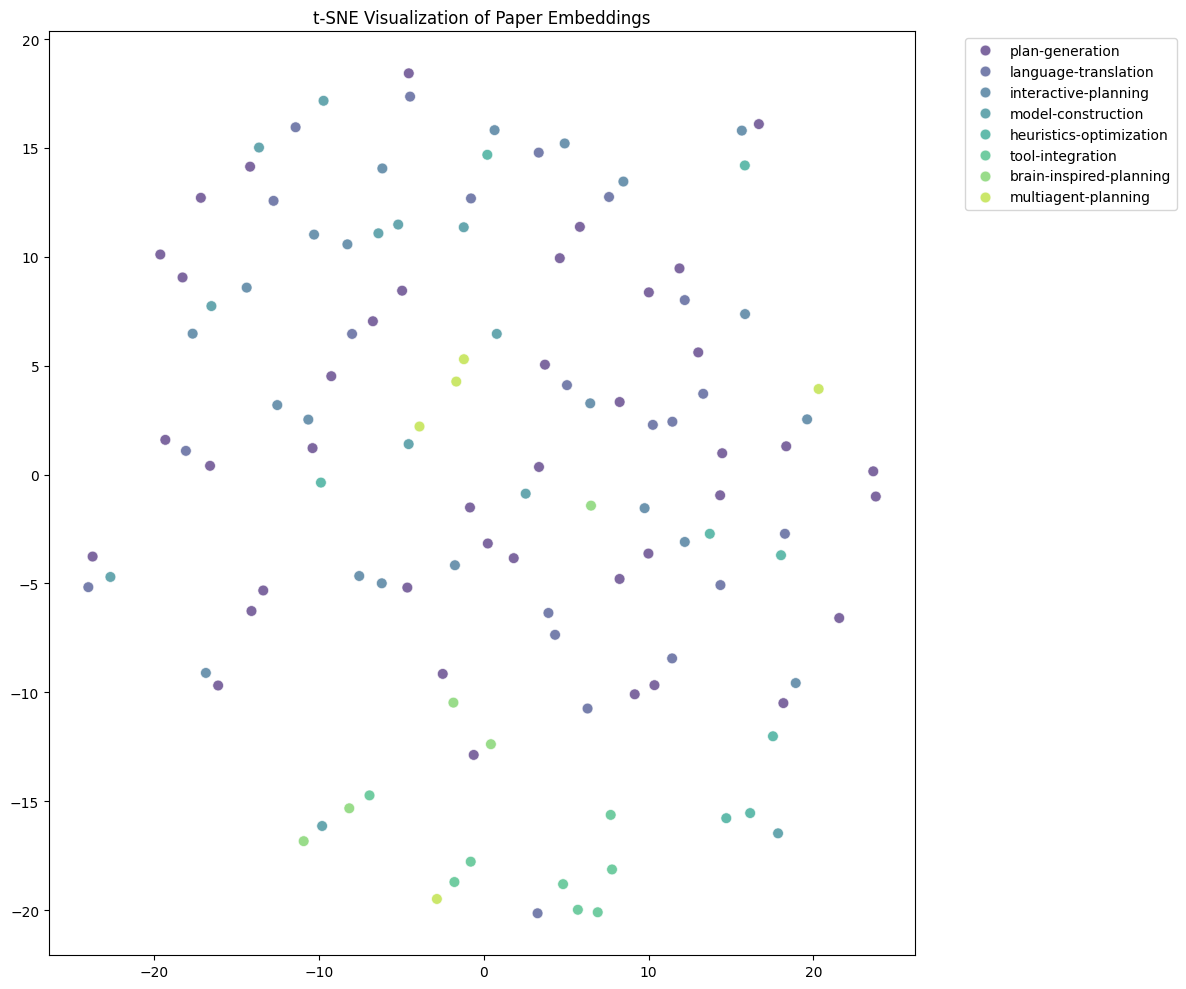

In [21]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X)
X_svd = normalize(X_svd)

print("\n=== t-SNE Visualization ===")
try:
    perp = 15
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perp,
        init="pca",
        learning_rate="auto"
    )
    X_embedded = tsne.fit_transform(X_svd)
        
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x=X_embedded[:, 0], 
        y=X_embedded[:, 1], 
        hue=df['primary_category'], 
        palette='viridis', 
        s=60,
        alpha=0.7
    )
    plt.title("t-SNE Visualization of Paper Embeddings")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"t-SNE failed: {e}")

In [22]:
print("\n=== Top TF-IDF Terms per Class ===")
for cat in unique_cats:
    cat_indices = df[df['primary_category'] == cat].index
    if len(cat_indices) == 0: continue
    
    # Mean vector for the category
    cat_mean_vec = np.asarray(X[cat_indices].mean(axis=0)).flatten()
    # Top 10 indices
    top_indices = cat_mean_vec.argsort()[::-1][:10]
    top_terms = feature_names[top_indices]
    
    print(f"Category: '{cat}' (n={len(cat_indices)})")
    print(f"  Top Terms: {', '.join(top_terms)}")


=== Top TF-IDF Terms per Class ===
Category: 'plan-generation' (n=41)
  Top Terms: reasoning, plan, task, generation, plans, knowledge, prompting, capabilities, llm, symbolic
Category: 'language-translation' (n=21)
  Top Terms: task, natural, natural language, reasoning, symbolic, knowledge, planners, narrative, logical, scene
Category: 'interactive-planning' (n=21)
  Top Terms: feedback, embodied, reasoning, actions, llm, model, natural language, natural, environment, plan
Category: 'model-construction' (n=12)
  Top Terms: agent, knowledge, world, task, policy, agents, cognitive, human, skills, embodied
Category: 'heuristics-optimization' (n=8)
  Top Terms: heuristic, reasoning, function, llm, guidance, search, model, plans, domain, training
Category: 'tool-integration' (n=8)
  Top Terms: tools, tool, ai, agents, usage, various, intelligence, apis, artificial, external
Category: 'brain-inspired-planning' (n=5)
  Top Terms: cognitive, fast, agents, systematic, module, reasoning, evalu


=== Text Length ===
primary_category
tool-integration           209.750000
interactive-planning       206.047619
heuristics-optimization    203.000000
brain-inspired-planning    196.600000
multiagent-planning        195.600000
language-translation       195.238095
plan-generation            193.048780
model-construction         182.666667
Name: text_len, dtype: float64


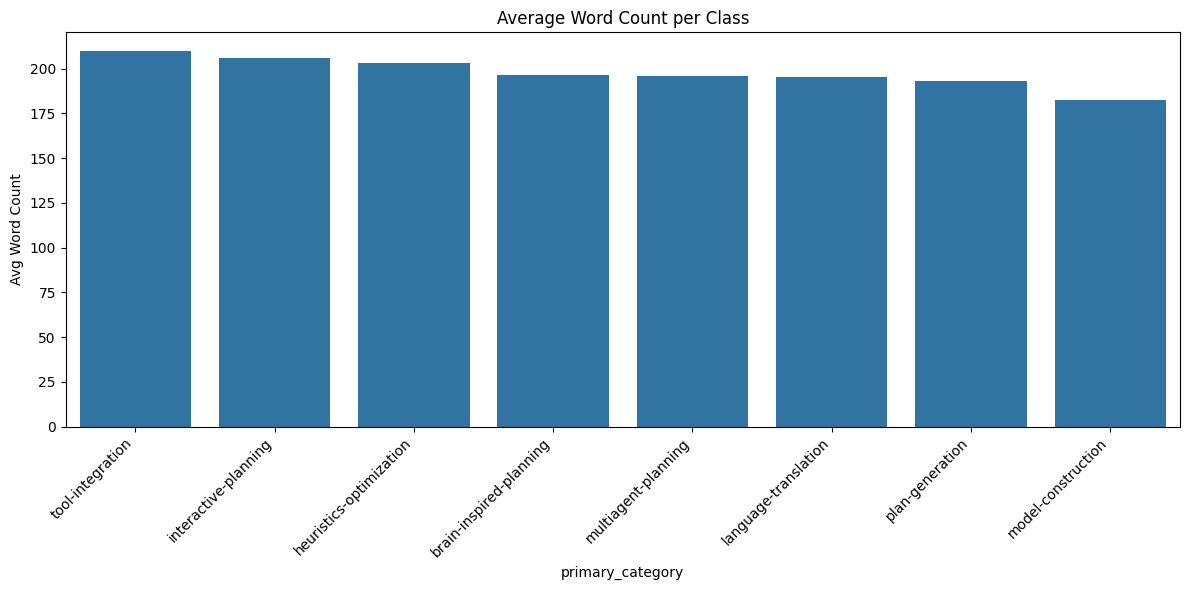

In [23]:
print("\n=== Text Length ===")
df['text_len'] = df['clean_text'].apply(lambda x: len(x.split())) # Word count
avg_len = df.groupby('primary_category')['text_len'].mean().sort_values(ascending=False)
print(avg_len)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_len.index, y=avg_len.values)
plt.title("Average Word Count per Class")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Avg Word Count")
plt.tight_layout()
plt.show()

In [24]:
print("\n=== Silhouette Score ===")
le = LabelEncoder()
y = le.fit_transform(df["primary_category"])
sil = silhouette_score(X, y, metric="cosine")
print(f"Silhouette Score (Global): {sil:.4f}")



=== Silhouette Score ===
Silhouette Score (Global): -0.0104


In [25]:
print("\n=== N-gram Overlap (Top 20 Terms) ===")
# Construct sets of top terms for each category
cat_terms_set = {}
for cat in unique_cats:
    cat_indices = df[df['primary_category'] == cat].index
    if len(cat_indices) == 0: continue
    cat_mean_vec = np.asarray(X[cat_indices].mean(axis=0)).flatten()
    top_indices = cat_mean_vec.argsort()[::-1][:20]
    cat_terms_set[cat] = set(feature_names[top_indices])

# Pairwise overlap
cats_list = list(unique_cats)
for i in range(len(cats_list)):
    for j in range(i+1, len(cats_list)):
        c1 = cats_list[i]
        c2 = cats_list[j]
        overlap = cat_terms_set[c1].intersection(cat_terms_set[c2])
        print(f"Overlap '{c1}' vs '{c2}': {len(overlap)} terms")
        if overlap:
            print(f"  Shared: {', '.join(list(overlap)[:10])}")
        print("")


=== N-gram Overlap (Top 20 Terms) ===
Overlap 'plan-generation' vs 'language-translation': 7 terms
  Shared: knowledge, plans, robot, llm, task, reasoning, symbolic

Overlap 'plan-generation' vs 'interactive-planning': 9 terms
  Shared: model, approach, action, robot, llm, task, reasoning, plan, embodied

Overlap 'plan-generation' vs 'model-construction': 7 terms
  Shared: knowledge, agents, llm, task, reasoning, plan, embodied

Overlap 'plan-generation' vs 'heuristics-optimization': 4 terms
  Shared: llm, model, reasoning, plans

Overlap 'plan-generation' vs 'tool-integration': 2 terms
  Shared: agents, reasoning

Overlap 'plan-generation' vs 'brain-inspired-planning': 2 terms
  Shared: agents, reasoning

Overlap 'plan-generation' vs 'multiagent-planning': 3 terms
  Shared: agents, embodied, task

Overlap 'language-translation' vs 'interactive-planning': 6 terms
  Shared: natural, natural language, robot, llm, task, reasoning

Overlap 'language-translation' vs 'model-construction': 5

In [26]:
for cat in unique_cats:
    cat_terms = cat_terms_set[cat]
    other_terms = set().union(*[cat_terms_set[c] for c in unique_cats if c != cat])
    unique_terms = cat_terms - other_terms
    print(f"Unique terms in '{cat}': {len(unique_terms)}")
    print(", ".join(sorted(unique_terms)))
    print("")

Unique terms in 'plan-generation': 7
capabilities, generation, objects, plan generation, prompting, solving, using

Unique terms in 'language-translation': 10
framework, grounding, instructions, logical, narrative, planner, planners, problems, robotic, scene

Unique terms in 'interactive-planning': 4
environment, environments, feedback, prompt

Unique terms in 'model-construction': 7
commonsense, interactions, planning tasks, policy, rl, robots, skill

Unique terms in 'heuristics-optimization': 15
cot, domain, domains, exploration, function, generate, given, guidance, guide, heuristic, new, pddl, search, semantic, training

Unique terms in 'tool-integration': 14
abilities, apis, artificial, demonstrations, enabling, execute, external, external tools, intelligence, tool, tools, usage, use, various

Unique terms in 'brain-inspired-planning': 14
components, efficiency, fast, interactive, map, maps, modular, module, modules, reasoning tasks, slow, systematic, thinking, trajectories

Unique